In [1]:
from pathlib import Path
import sys 
import sumolib

ROOT_DIR = Path.cwd().parent.parent
# add to sys path, to find module for dependencies
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))
    
from scripts.src.operations.cmd import run_marouter
import scripts.src.inputs.config as cfg
import scripts.src.operations.assignment as AS

In [ ]:
import xml.etree.ElementTree as ET

def load_traveltimes(path, aggregation="max"):
    tree = ET.parse(path)
    samples = {}  # edge_id -> list of (traveltime, sampledSeconds)

    for interval in tree.getroot().findall("interval"):
        for edge in interval.findall("edge"):
            sampled = float(edge.get("sampledSeconds", 0))
            if sampled <= 0:
                continue  # nessun veicolo transitato in questo intervallo: ignora
            tt = edge.get("traveltime")
            if tt is None:
                continue
            eid = edge.get("id")
            samples.setdefault(eid, []).append((float(tt), sampled))

    result = {}
    for eid, vals in samples.items():
        if aggregation == "max":
            result[eid] = max(v[0] for v in vals)
        elif aggregation == "weighted_mean":
            total_w = sum(v[1] for v in vals)
            result[eid] = sum(v[0] * v[1] for v in vals) / total_w
    return result

tt_r0 = load_traveltimes("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_PM/edge_weights_r1_blended.xml")
tt_r1 = load_traveltimes("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_PM/edge_weights_r2_blended.xml")
tt_r2 = load_traveltimes("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_PM/edge_weights_r3_blended.xml")

# crytical corridor
for eid in ["1113770110#0", "121952561#0", "154986388#0"]:
    print(f"{eid}: r0={tt_r0.get(eid)}, r1={tt_r1.get(eid)},  r2={tt_r2.get(eid)}")
    # print(eid, tt_r1.get(eid))

1113770110#0: r0=1.2, r1=1.4120803396472894,  r2=1.4147491746463863
121952561#0: r0=0.31, r1=4.807473311836709,  r2=2.7033052739675836
154986388#0: r0=1.57, r1=14.744756087031602,  r2=8.982519874256733


In [ ]:
def convergence_metric_absolute(prev_weight_file, curr_weight_file) -> dict:
    
    prev_tt = load_traveltimes(prev_weight_file, aggregation="weighted_mean")

    tree = ET.parse(curr_weight_file)
    curr_samples = {}
    for interval in tree.getroot().findall("interval"):
        for edge in interval.findall("edge"):
            sampled = float(edge.get("sampledSeconds", 0))
            tt = edge.get("traveltime")
            if sampled <= 0 or tt is None:
                continue
            eid = edge.get("id")
            curr_samples.setdefault(eid, []).append((float(tt), sampled))

    curr_tt, curr_weight = {}, {}
    for eid, vals in curr_samples.items():
        total_w = sum(v[1] for v in vals)
        curr_tt[eid] = sum(v[0] * v[1] for v in vals) / total_w
        curr_weight[eid] = total_w

    common_edges = set(prev_tt) & set(curr_tt)
    if not common_edges:
        return {"n_edges": 0, "weighted_rmse_abs": None, "max_abs_diff": None}

    total_weight = sum(curr_weight[e] for e in common_edges)
    weighted_sq_abs_diff = 0.0
    max_abs_diff = 0.0
    max_abs_edge = None

    for e in common_edges:
        old, new, w = prev_tt[e], curr_tt[e], curr_weight[e]
        abs_diff = abs(new - old)
        weighted_sq_abs_diff += w * (abs_diff ** 2)
        if abs_diff > max_abs_diff:
            max_abs_diff = abs_diff
            max_abs_edge = e

    weighted_rmse_abs = (weighted_sq_abs_diff / total_weight) ** 0.5

    return {
        "n_edges": len(common_edges),
        "weighted_rmse_abs": weighted_rmse_abs,  # SECONDI, non percentuale
        "max_abs_diff": max_abs_diff,
        "max_abs_edge": max_abs_edge,
    }

In [21]:
results = []
work_dir = cfg.WORKDIRS['MA_no_TLS']['PM']  # verifica sia la cartella giusta

for r in range(1, 10):
    prev_file = work_dir / f"edge_weights_r{r}_blended.xml" if r > 1 else work_dir / f"edge_weights_r1.xml"
    curr_file = work_dir / f"edge_weights_r{r+1}_blended.xml"
    m = convergence_metric_absolute(prev_file, curr_file)
    print(f"Round {r}→{r+1}: variazione media pesata = {m['weighted_rmse_abs']:.2f}s, "
          f"edge più variato = {m['max_abs_edge']} ({m['max_abs_diff']:.1f}s), "
          f"edge confrontati = {m['n_edges']}")
    results.append(m)

Round 1→2: variazione media pesata = 467.13s, edge più variato = 1306068766#0 (8971.0s), edge confrontati = 1366
Round 2→3: variazione media pesata = 550.40s, edge più variato = 1306068766#0 (2775.2s), edge confrontati = 1122
Round 3→4: variazione media pesata = 923.93s, edge più variato = 543492893#1 (4325.3s), edge confrontati = 990
Round 4→5: variazione media pesata = 1289.51s, edge più variato = -447701119#0 (3669.7s), edge confrontati = 970
Round 5→6: variazione media pesata = 180.34s, edge più variato = 36357298#2 (876.7s), edge confrontati = 885
Round 6→7: variazione media pesata = 140.85s, edge più variato = -211479424#1 (587.8s), edge confrontati = 855
Round 7→8: variazione media pesata = 181.01s, edge più variato = -904270744 (1875.4s), edge confrontati = 941
Round 8→9: variazione media pesata = 111.90s, edge più variato = 154986384#5 (712.5s), edge confrontati = 854
Round 9→10: variazione media pesata = 83.87s, edge più variato = 1311101659#7 (240.0s), edge confrontati = 897

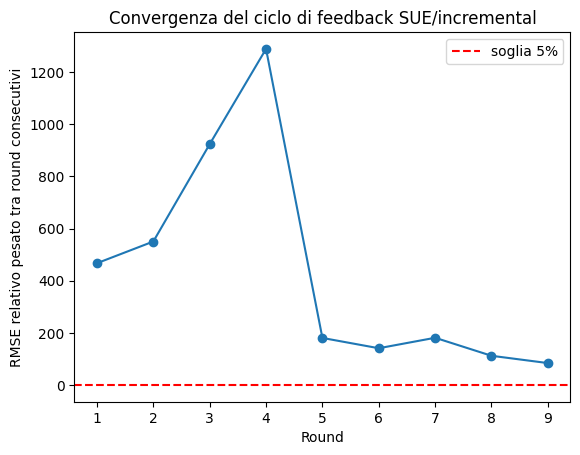

In [22]:
import matplotlib.pyplot as plt

rounds = list(range(1, len(results) + 1))
rmse_values = [m["weighted_rmse_abs"] for m in results]

plt.plot(rounds, rmse_values, marker="o")
plt.axhline(y=0.05, color="r", linestyle="--", label="soglia 5%")
plt.xlabel("Round")
plt.ylabel("RMSE relativo pesato tra round consecutivi")
plt.title("Convergenza del ciclo di feedback SUE/incremental")
plt.legend()
plt.savefig("convergenza.png")

In [23]:
from collections import Counter

def edges_used_on_corridor(marouter_output_path, corridor_prefixes):
    tree = ET.parse(marouter_output_path)
    root = tree.getroot()
    counts = Counter()
    for veh in root.findall("vehicle") + root.findall("trip"):
        route_el = _select_route_element(veh)  # riusa la funzione già pronta
        if route_el is None:
            continue
        edges = route_el.get("edges", "").split()
        for e in edges:
            if any(e.lstrip("-").startswith(p) for p in corridor_prefixes):
                counts[e] += 1
    return counts

corridor = ["1113770110", "121952561", "154986388"]
c0 = edges_used_on_corridor("marouter_output_clean_r0.rou.xml", corridor)
c1 = edges_used_on_corridor("marouter_output_clean_r1.rou.xml", corridor)
print("Round 0:", dict(c0))
print("Round 1:", dict(c1))

FileNotFoundError: [Errno 2] No such file or directory: 'marouter_output_clean_r0.rou.xml'

In [ ]:
from scripts.src.operations.assignment import _select_route_element, _taz_edge_ids
from collections import Counter

def edges_used_on_corridor(marouter_output_path, corridor_prefixes):
    tree = ET.parse(marouter_output_path)
    root = tree.getroot()
    counts = Counter()
    for veh in root.findall("vehicle") + root.findall("trip"):
        route_el = _select_route_element(veh)  # riusa la funzione già pronta
        if route_el is None:
            continue
        edges = route_el.get("edges", "").split()
        for e in edges:
            if any(e.lstrip("-").startswith(p) for p in corridor_prefixes):
                counts[e] += 1
    return counts

corridor = ["1113770110", "121952561", "154986388"]

In [ ]:
def check_alternatives_avoid_corridor(routes_file, corridor_edges):
    tree = ET.parse(routes_file)
    root = tree.getroot()

    n_only_one_route = 0
    n_all_alts_use_corridor = 0
    n_some_alt_avoids_corridor = 0
    examples_avoiding = []

    for veh in root.findall("vehicle") + root.findall("trip"):
        rd = veh.find("routeDistribution")
        if rd is None:
            continue
        routes = rd.findall("route")
        if len(routes) <= 1:
            continue  # nessuna alternativa da confrontare

        # chekc se la route scelta usa il corridoio
        best = max(routes, key=lambda r: float(r.get("probability", 0) or 0))
        best_edges = set(best.get("edges", "").split())
        if not (corridor_edges & best_edges):
            continue

        any_avoids = False # check se tra tutte le alternative si evita corridoio
        for r in routes:
            r_edges = set(r.get("edges", "").split())
            if not (corridor_edges & r_edges):
                any_avoids = True
                if len(examples_avoiding) < 5:
                    examples_avoiding.append({
                        "veh_id": veh.get("id"),
                        "n_alternatives": len(routes),
                        "avoiding_route_prob": r.get("probability"),
                        "avoiding_route_edges": len(r_edges),
                    })
                break

        if any_avoids:
            n_some_alt_avoids_corridor += 1
        else:
            n_all_alts_use_corridor += 1

    print(f"Veicoli con route primaria sul corridoio E >1 alternativa: "
          f"{n_all_alts_use_corridor + n_some_alt_avoids_corridor}")
    print(f"  - TUTTE le alternative passano comunque dal corridoio: {n_all_alts_use_corridor}")
    print(f"  - Almeno un'alternativa EVITA il corridoio: {n_some_alt_avoids_corridor}")
    if examples_avoiding:
        print("\nEsempi di alternative che evitano il corridoio (scartate da marouter):")
        for ex in examples_avoiding:
            print(f"  {ex}")

corridor_edges = {"1113770110#1", "1113770110#2", "121952561#0", "121952561#1",
                   "121952561#2", "121952561#3", "154986388#0", "154986388#1",
                   "154986388#2", "154986388#3"}

check_alternatives_avoid_corridor(routes_final_0, corridor_edges)

Veicoli con route primaria sul corridoio E >1 alternativa: 1526
  - TUTTE le alternative passano comunque dal corridoio: 481
  - Almeno un'alternativa EVITA il corridoio: 1045

Esempi di alternative che evitano il corridoio (scartate da marouter):
  {'veh_id': '15462', 'n_alternatives': 10, 'avoiding_route_prob': '80.16000000', 'avoiding_route_edges': 37}
  {'veh_id': '15053', 'n_alternatives': 8, 'avoiding_route_prob': '16.36000000', 'avoiding_route_edges': 7}
  {'veh_id': '15463', 'n_alternatives': 10, 'avoiding_route_prob': '80.16000000', 'avoiding_route_edges': 37}
  {'veh_id': '15054', 'n_alternatives': 8, 'avoiding_route_prob': '16.36000000', 'avoiding_route_edges': 7}
  {'veh_id': '15464', 'n_alternatives': 10, 'avoiding_route_prob': '80.16000000', 'avoiding_route_edges': 37}


In [ ]:
tree = ET.parse("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/VehTraces_marouter1_AM.xml")  # il vehroute-output reale, non l'output di marouter
root = tree.getroot()

target_ids = {"15462", "15463", "15464", "15053", "15054"}
for veh in root.findall("vehicle"):
    if veh.get("id") in target_ids:
        route_el = veh.find("route")
        edges = route_el.get("edges", "").split() if route_el is not None else []
        uses_corridor = bool(corridor_edges & set(edges))
        print(f"veh {veh.get('id')}: route REALMENTE usata in simulazione, "
              f"{'PASSA dal corridoio' if uses_corridor else 'EVITA il corridoio'}, "
              f"{len(edges)} edge")

veh 15462: route REALMENTE usata in simulazione, EVITA il corridoio, 40 edge
veh 15053: route REALMENTE usata in simulazione, EVITA il corridoio, 11 edge
veh 15463: route REALMENTE usata in simulazione, EVITA il corridoio, 41 edge
veh 15054: route REALMENTE usata in simulazione, EVITA il corridoio, 12 edge
veh 15464: route REALMENTE usata in simulazione, EVITA il corridoio, 56 edge


In [ ]:
tree = ET.parse("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/VehTraces_marouter1_AM.xml")
root = tree.getroot()


corridor_edges = {"1113770110#1", "1113770110#2", "121952561#0", "121952561#1",
                   "121952561#2", "121952561#3", "154986388#0", "154986388#1",
                   "154986388#2", "154986388#3"}
n_total_via_corridor_planned = 0
n_total_via_corridor_actual = 0

for veh in root.findall(".//vehicle"):
    route_el = veh.find("route")
    if route_el is None:
        continue
    edges = set(route_el.get("edges", "").split())
    if corridor_edges & edges:
        n_total_via_corridor_actual += 1



print(f"Veicoli che attraversano TEORICAMENTE il corridoio in simulazione: {n_total_via_corridor_planned}")
print(f"Veicoli che attraversano DAVVERO il corridoio in simulazione: {n_total_via_corridor_actual}")

Veicoli che attraversano TEORICAMENTE il corridoio in simulazione: 0
Veicoli che attraversano DAVVERO il corridoio in simulazione: 1044
